In [1]:
import sys
import types

cgi = types.ModuleType('cgi')
sys.modules['cgi'] = cgi

In [2]:
import matplotlib.pyplot as plt
import nltk
import pandas as pd
import re
import tensorflow as tf

from corus import load_lenta
from itertools import islice
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn import metrics
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from wordcloud import WordCloud, STOPWORDS

Загрузка датасета

In [3]:
records = load_lenta(path='lenta-ru-news.csv.gz')
data = pd.DataFrame([
    {'title': record.title, 'topic': record.topic} 
    for record in islice(records, 10000)
])
data

,title,topic
0,Названы регионы России с самой высокой смертно...,Россия
1,Австрия не представила доказательств вины росс...,Спорт
2,Обнаружено самое счастливое место на планете,Путешествия
3,В США раскрыли сумму расходов на расследование...,Мир
4,Хакеры рассказали о планах Великобритании зами...,Мир
...,...,...
9995,Судей обвинили в занижении оценок Загитовой,Спорт
9996,Обнаружено новое ворующее деньги приложение,Интернет и СМИ
9997,Смертельно больной ветеран распродал пожитки р...,Из жизни
9998,Китайских чиновников накажут за пышные свадьбы...,Мир


Облако слов

(np.float64(-0.5), np.float64(2999.5), np.float64(2999.5), np.float64(-0.5))

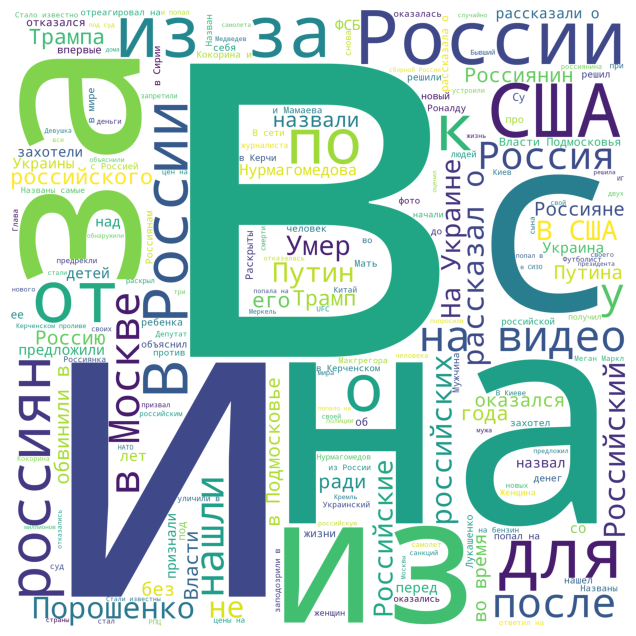

In [4]:
corpus = []
for title in data.title:
    for word in title.split():
        corpus.append(word)

word_cloud = WordCloud(
    background_color='white',
    stopwords=STOPWORDS,
    width=3000,
    height=3000,
    max_words=200,
    random_state=42
).generate(' '.join(corpus))

fig = plt.figure(figsize=(20, 8))
plt.subplot(1, 2, 1)
plt.imshow(word_cloud)
plt.axis('off')

Предобработка данных

In [5]:
nltk.download("stopwords")
stop_words = set(stopwords.words('russian'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    words = re.sub(r'[^\w\s]', ' ', text.lower()).split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return ' '.join(words)

data['title_clean'] = data.title.apply(clean_text)
data

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Timofey\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,title,topic,title_clean
0,Названы регионы России с самой высокой смертно...,Россия,названы регионы россии самой высокой смертност...
1,Австрия не представила доказательств вины росс...,Спорт,австрия представила доказательств вины российс...
2,Обнаружено самое счастливое место на планете,Путешествия,обнаружено самое счастливое место планете
3,В США раскрыли сумму расходов на расследование...,Мир,сша раскрыли сумму расходов расследование росс...
4,Хакеры рассказали о планах Великобритании зами...,Мир,хакеры рассказали планах великобритании замини...
...,...,...,...
9995,Судей обвинили в занижении оценок Загитовой,Спорт,судей обвинили занижении оценок загитовой
9996,Обнаружено новое ворующее деньги приложение,Интернет и СМИ,обнаружено новое ворующее деньги приложение
9997,Смертельно больной ветеран распродал пожитки р...,Из жизни,смертельно больной ветеран распродал пожитки р...
9998,Китайских чиновников накажут за пышные свадьбы...,Мир,китайских чиновников накажут пышные свадьбы по...


Новое облако

(np.float64(-0.5), np.float64(2999.5), np.float64(2999.5), np.float64(-0.5))

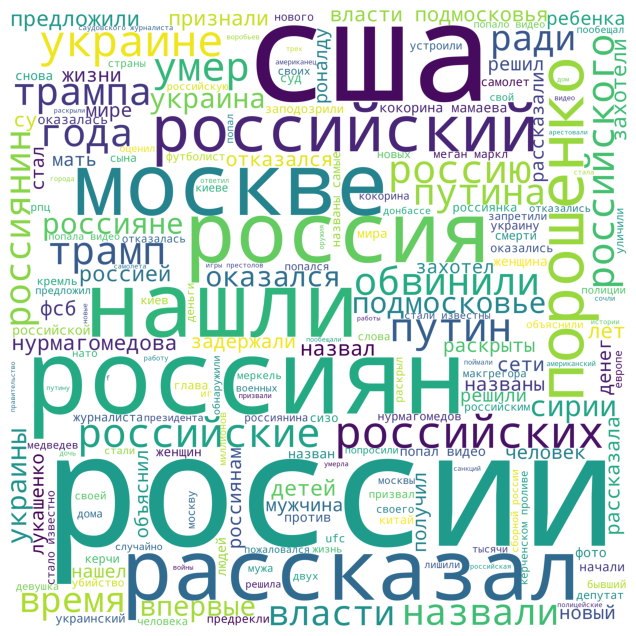

In [6]:
corpus = []
for title in data.title_clean:
    for word in title.split():
        corpus.append(word)

word_cloud = WordCloud(
    background_color='white',
    stopwords=STOPWORDS,
    width=3000,
    height=3000,
    max_words=200,
    random_state=42
).generate(' '.join(corpus))

fig = plt.figure(figsize=(20, 8))
plt.subplot(1, 2, 1)
plt.imshow(word_cloud)
plt.axis('off')

Группировка по темам

In [7]:
grouped_data = data.groupby('topic').count()
grouped_data

,title,title_clean
topic,,
,3,3
69-я параллель,78,78
Бизнес,1,1
Бывший СССР,751,751
Дом,287,287
Из жизни,663,663
Интернет и СМИ,701,701
Культура,688,688
Мир,1343,1343


Удалим темы с малым кол-во статей

In [8]:
df = data[~data['topic'].isin(['', 'Бизнес', '69-я параллель'])]

Разделим датасет на обучающую тестовую выборки

In [9]:
X_train, X_test, y_train, y_test = train_test_split(df.title_clean, df.topic, test_size=0.2, random_state=42)

Создание классификатора

In [10]:
model = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2))),
    ('sgd_clf', SGDClassifier(random_state=42))
])

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('sgd_clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


Оценка классификатора

In [11]:
pred = model.predict(X_test)
print(metrics.classification_report(pred, y_test))

                   precision    recall  f1-score   support

      Бывший СССР       0.84      0.74      0.79       154
              Дом       0.56      0.71      0.63        58
         Из жизни       0.63      0.61      0.62       136
   Интернет и СМИ       0.60      0.69      0.64       130
         Культура       0.71      0.68      0.70       138
              Мир       0.72      0.67      0.69       320
  Наука и техника       0.62      0.73      0.67       114
      Путешествия       0.47      0.57      0.51        51
           Россия       0.61      0.54      0.57       323
Силовые структуры       0.55      0.65      0.60       113
            Спорт       0.92      0.83      0.87       198
         Ценности       0.55      0.76      0.64        51
        Экономика       0.62      0.64      0.63       198

         accuracy                           0.67      1984
        macro avg       0.65      0.68      0.66      1984
     weighted avg       0.68      0.67      0.67      

Нейронная сеть

Кодирование целевой переменной

In [12]:
encoder = LabelEncoder()
df['topic_encoded'] = encoder.fit_transform(df.topic)
df

,title,topic,title_clean,topic_encoded
0,Названы регионы России с самой высокой смертно...,Россия,названы регионы россии самой высокой смертност...,8
1,Австрия не представила доказательств вины росс...,Спорт,австрия представила доказательств вины российс...,10
2,Обнаружено самое счастливое место на планете,Путешествия,обнаружено самое счастливое место планете,7
3,В США раскрыли сумму расходов на расследование...,Мир,сша раскрыли сумму расходов расследование росс...,5
4,Хакеры рассказали о планах Великобритании зами...,Мир,хакеры рассказали планах великобритании замини...,5
...,...,...,...,...
9995,Судей обвинили в занижении оценок Загитовой,Спорт,судей обвинили занижении оценок загитовой,10
9996,Обнаружено новое ворующее деньги приложение,Интернет и СМИ,обнаружено новое ворующее деньги приложение,3
9997,Смертельно больной ветеран распродал пожитки р...,Из жизни,смертельно больной ветеран распродал пожитки р...,2
9998,Китайских чиновников накажут за пышные свадьбы...,Мир,китайских чиновников накажут пышные свадьбы по...,5


Токенизация

In [13]:
tokenizer = tf.keras.preprocessing.text.Tokenizer(num_words=10000, oov_token='<OOV>')
tokenizer.fit_on_texts(df.title_clean)

sequences = tokenizer.texts_to_sequences(df.title_clean)
padded_sequences = tf.keras.preprocessing.sequence.pad_sequences(sequences, maxlen=100, padding='post', truncating='post')


Подготовка выборок

In [14]:
y = tf.keras.utils.to_categorical(df.topic_encoded.values, len(encoder.classes_))

X_train, X_test, y_train, y_test = train_test_split(
    padded_sequences, y, 
    test_size=0.2, 
    random_state=42,
    stratify=df.topic_encoded.values
)

Создание архитектуры

In [ ]:
model = tf.keras.Sequential([
    
    tf.keras.layers.Embedding(10000, 100, input_length=100),
    
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, return_sequences=True)),
   
    tf.keras.layers.Dropout(0.5),
    
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32)),    
    
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(32, activation='relu'),  
    
    tf.keras.layers.Dense(len(encoder.classes_), activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


d:\unik\ai_methods\venv\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Обучение модели

In [28]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_learning_rate = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=0.0001
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping, reduce_learning_rate],
    verbose=1
)

Epoch 1/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 18s 58ms/step - accuracy: 0.1451 - loss: 2.4439 - val_accuracy: 0.1709 - val_loss: 2.2951 - learning_rate: 0.0010
Epoch 2/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 13s 52ms/step - accuracy: 0.2221 - loss: 2.1336 - val_accuracy: 0.3004 - val_loss: 2.0214 - learning_rate: 0.0010
Epoch 3/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 13s 53ms/step - accuracy: 0.4215 - loss: 1.6367 - val_accuracy: 0.4057 - val_loss: 1.8658 - learning_rate: 0.0010
Epoch 4/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 13s 54ms/step - accuracy: 0.6112 - loss: 1.1405 - val_accuracy: 0.4763 - val_loss: 1.7257 - learning_rate: 0.0010
Epoch 5/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 15s 58ms/step - accuracy: 0.7276 - loss: 0.8066 - val_accuracy: 0.5030 - val_loss: 1.8702 - learning_rate: 0.0010
Epoch 6/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 16s 66ms/step - accuracy: 0.8161 - loss: 0.5884 - val_accuracy: 0.4955 - val_loss: 2.2090 - learning_rate: 0.0010
Epoch 7/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 16s 66ms/step - accuracy: 0.8631 - l

Оценка модели и визуализация обучения

In [29]:
loss, accuracy = model.evaluate(X_test, y_test)
loss, accuracy

62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.4763 - loss: 1.7257


(1.7257075309753418, 0.47631049156188965)

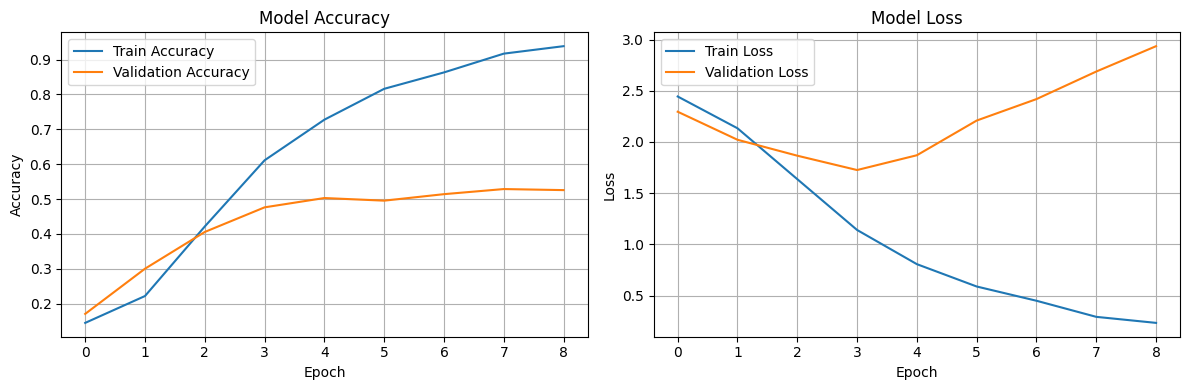

In [30]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'], label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)
   

ax2.plot(history.history['loss'], label='Train Loss')
ax2.plot(history.history['val_loss'], label='Validation Loss')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)
   
plt.tight_layout()
plt.show()